In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('default')
sns.set(style="whitegrid")
%matplotlib inline


In [3]:
df = pd.read_csv('data/e-shop_cleaned_final.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (165474, 17)
Columns: ['year', 'month', 'day', 'order', 'country', 'session_id', 'main_category', 'clothing_model', 'colour', 'location', 'model_photography', 'price', 'price_2', 'page', 'date', 'day_of_week', 'main_category_name']


In [5]:
# Group by session to understand user journeys
session_df = df.groupby('session_id').agg(
    total_clicks=('order', 'count'),
    unique_categories=('main_category', 'nunique'),
    unique_products=('clothing_model', 'nunique'),
    total_price=('price', 'sum'),
    country=('country', 'first'),
    main_categories=('main_category_name', lambda x: list(x)),
    date=('date', 'first'),
    day_of_week=('day_of_week', 'first')
).reset_index()

print("Session analysis", session_df)

print("Session Analysis Summary:")
print(session_df.describe())

print("\nAverage clicks per session:", round(session_df['total_clicks'].mean(), 2))

Session analysis        session_id  total_clicks  unique_categories  unique_products  \
0               1             9                  4                9   
1               2            10                  3                8   
2               3             6                  3                6   
3               4             4                  2                4   
4               5             1                  1                1   
...           ...           ...                ...              ...   
24021       24022             3                  1                3   
24022       24023             7                  2                7   
24023       24024             1                  1                1   
24024       24025             1                  1                1   
24025       24026             3                  3                3   

       total_price  country  \
0              379       29   
1              500       29   
2              253       21   
3     

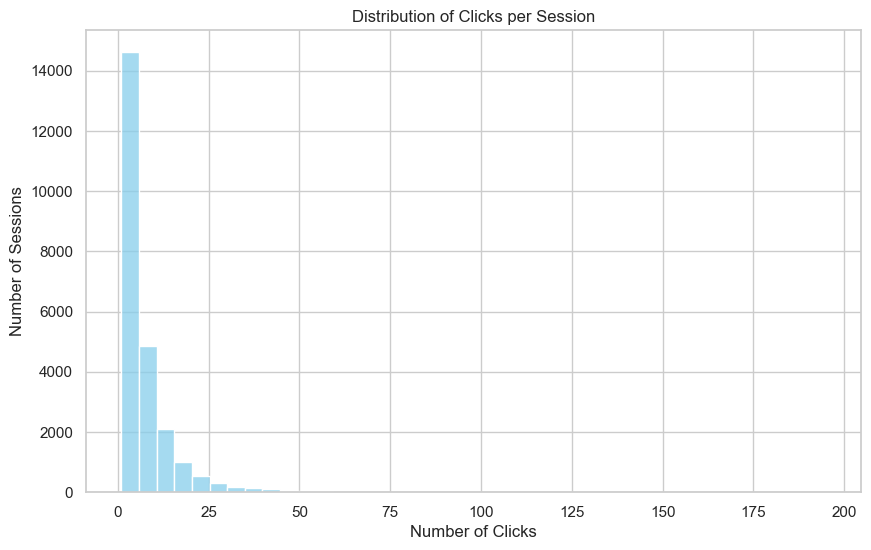

In [6]:
# Distribution of clicks per session
plt.figure(figsize=(10, 6))
sns.histplot(data=session_df, x='total_clicks', bins=40, color='skyblue')
plt.title('Distribution of Clicks per Session')
plt.xlabel('Number of Clicks')
plt.ylabel('Number of Sessions')
plt.show()

=== Top Main Categories ===
main_category_name
Trousers    49742
Sale        38747
Blouses     38577
Skirts      38408
Name: count, dtype: int64


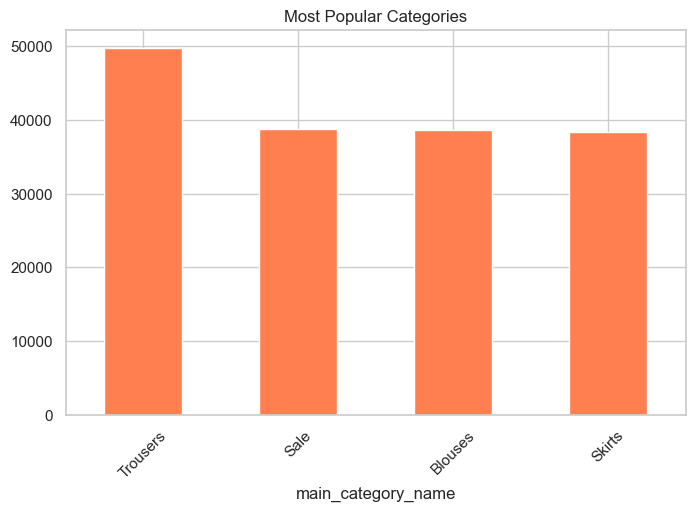

In [7]:
# Top Categories
print("=== Top Main Categories ===")
print(df['main_category_name'].value_counts())

plt.figure(figsize=(8,5))
df['main_category_name'].value_counts().plot(kind='bar', color='coral')
plt.title('Most Popular Categories')
plt.xticks(rotation=45)
plt.show()


=== Top 10 Countries ===
country
29    133963
9      18003
24      4091
46      2522
44      1385
16       834
21       811
34       716
41       684
3        256
Name: count, dtype: int64


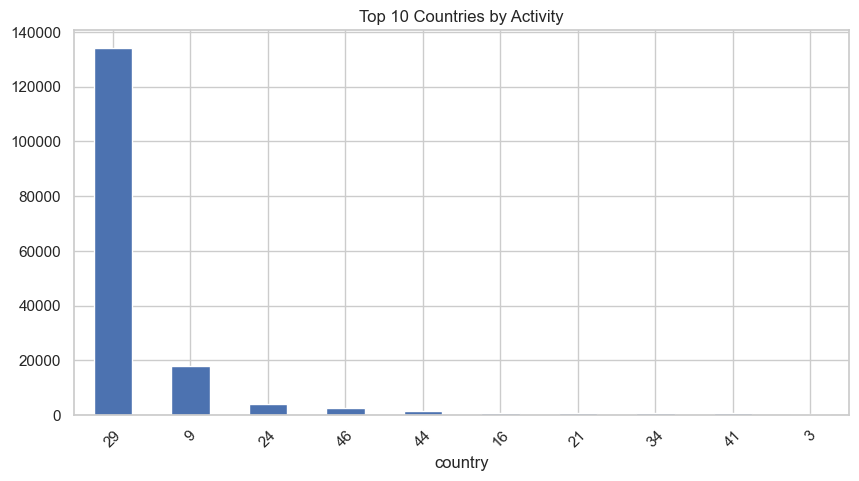

In [8]:
# Top Countries
print("\n=== Top 10 Countries ===")
print(df['country'].value_counts().head(10))

plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Activity')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Most common short paths (sequences of categories)
def get_path(seq):
    return tuple(seq[:5])  # First 5 clicks max

paths = df.groupby('session_id')['main_category_name'].apply(list)
common_paths = Counter(get_path(seq) for seq in paths)

print("=== Most Common User Paths (Category Sequences) ===")
for path, count in common_paths.most_common(15):
    print(path, "→", count, "sessions")

=== Most Common User Paths (Category Sequences) ===
('Trousers', 'Trousers', 'Trousers', 'Trousers', 'Trousers') → 2144 sessions
('Trousers',) → 1659 sessions
('Skirts',) → 1451 sessions
('Skirts', 'Skirts', 'Skirts', 'Skirts', 'Skirts') → 1295 sessions
('Blouses',) → 1170 sessions
('Trousers', 'Trousers') → 803 sessions
('Sale', 'Sale', 'Sale', 'Sale', 'Sale') → 778 sessions
('Sale',) → 762 sessions
('Skirts', 'Skirts') → 743 sessions
('Blouses', 'Blouses', 'Blouses', 'Blouses', 'Blouses') → 737 sessions
('Skirts', 'Skirts', 'Skirts') → 485 sessions
('Trousers', 'Trousers', 'Trousers') → 472 sessions
('Blouses', 'Blouses') → 404 sessions
('Sale', 'Sale') → 355 sessions
('Trousers', 'Trousers', 'Trousers', 'Trousers') → 272 sessions


In [10]:
# Bounce rate approximation (sessions with only 1 click)
single_click_sessions = len(session_df[session_df['total_clicks'] == 1])
total_sessions = len(session_df)
bounce_rate = (single_click_sessions / total_sessions) * 100

print(f"\nBounce Rate (1-click sessions): {bounce_rate:.1f}%")


Bounce Rate (1-click sessions): 21.0%


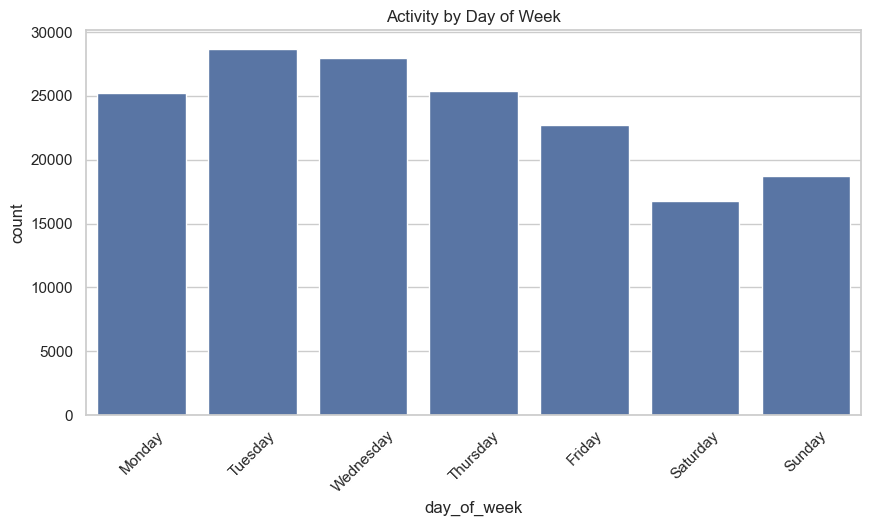

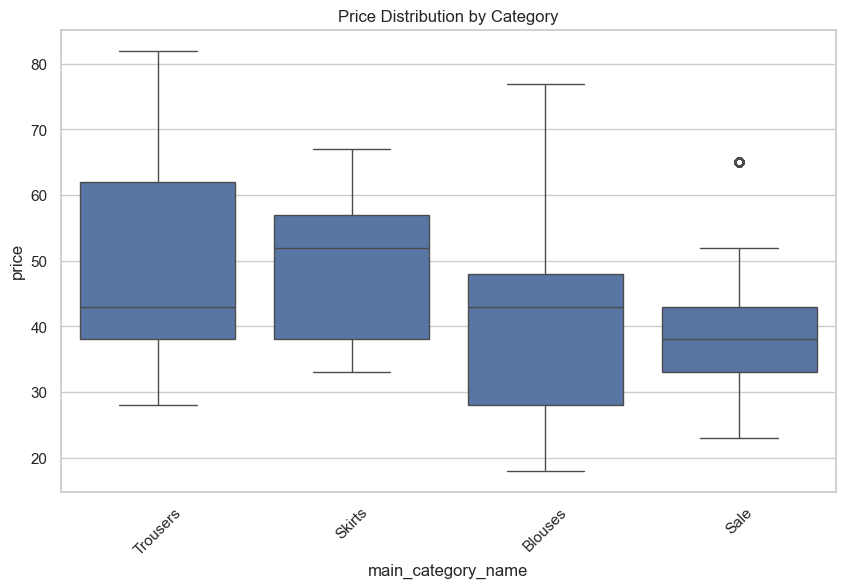

In [11]:
# Activity by Day of Week
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='day_of_week', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Activity by Day of Week')
plt.xticks(rotation=45)
plt.show()

# Price vs Category
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='main_category_name', y='price')
plt.title('Price Distribution by Category')
plt.xticks(rotation=45)
plt.show()